In [23]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Generate a synthetic dataset
np.random.seed(100)
data_X = np.random.rand(200, 1) * 10  # 200 data points between 0 and 10
data_y = 3.0 * data_X + np.random.randn(200, 1) * 1.5  # True relationship: y = 3.0x + noise




In [24]:
# Convert to PyTorch tensors
data_X_tensor = torch.tensor(data_X, dtype=torch.float32)
data_y_tensor = torch.tensor(data_y, dtype=torch.float32)

In [25]:
# Define a simple linear regression model
class SimpleLinearModel(nn.Module):
    def __init__(self):
        super(SimpleLinearModel, self).__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True))  # Parameter for weight
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True))    # Parameter for bias

    def forward(self, x):
        return self.weight * x + self.bias


# Initialize model, loss function, and optimizer
model = SimpleLinearModel()
loss_function = nn.MSELoss()



In [26]:
# Optimization parameters
learning_rates = [0.01, 0.05, 0.005]  # Different learning rates to test
epochs = 500
lowest_mse = float('inf')
optimal_lr = None
optimal_params = {}


In [28]:
# Training loop for different learning rates
for lr in learning_rates:
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    epoch_losses = []

    for _ in range(epochs):
        predictions = model(data_X_tensor)
        loss = loss_function(predictions, data_y_tensor)
        epoch_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    final_loss = epoch_losses[-1]
    print(f"Learning Rate: {lr}, Final Loss: {final_loss}")

    # Save the best parameters
    if final_loss < lowest_mse:
        lowest_mse = final_loss
        optimal_lr = lr
        optimal_params['weight'] = model.weight.detach().item()
        optimal_params['bias'] = model.bias.detach().item()

# Adjust learning rate dynamically
adjust_factors = [0.5, 2.0]
for factor in adjust_factors:
    adjusted_lr = optimal_lr * factor
    optimizer = torch.optim.SGD(model.parameters(), lr=adjusted_lr)
    epoch_losses = []

    for _ in range(epochs):
        predictions = model(data_X_tensor)
        loss = loss_function(predictions, data_y_tensor)
        epoch_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    final_loss = epoch_losses[-1]
    print(f"Adjusted Learning Rate: {adjusted_lr}, Final Loss: {final_loss}")
    if final_loss < lowest_mse:
        lowest_mse = final_loss
        optimal_lr = adjusted_lr
        optimal_params['weight'] = model.weight.detach().item()
        optimal_params['bias'] = model.bias.detach().item()


Learning Rate: 0.01, Final Loss: nan
Learning Rate: 0.05, Final Loss: nan
Learning Rate: 0.005, Final Loss: nan
Adjusted Learning Rate: 0.005, Final Loss: nan
Adjusted Learning Rate: 0.02, Final Loss: nan


Optimal Learning Rate: 0.01
Lowest MSE: 2.587387800216675
Optimal Parameters: {'weight': 2.950301170349121, 'bias': 0.46077001094818115}


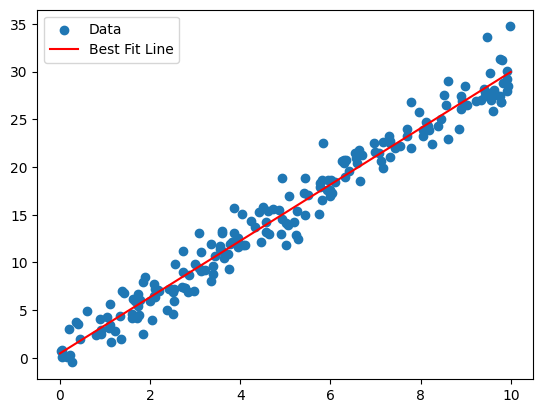

In [29]:
# Results
print(f"Optimal Learning Rate: {optimal_lr}")
print(f"Lowest MSE: {lowest_mse}")
print(f"Optimal Parameters: {optimal_params}")

# Plotting the best fit line
plt.scatter(data_X, data_y, label='Data')
best_fit_x = np.linspace(0, 10, 100).reshape(-1, 1)
best_fit_y = optimal_params['weight'] * best_fit_x + optimal_params['bias']
plt.plot(best_fit_x, best_fit_y, color='red', label='Best Fit Line')
plt.legend()
plt.show()